In [2]:

# 04 - Statistical Analysis
# Chi-square tests of independence for the key categorical relationships:
# Age <-> AI usage, Occupation <-> tool preference, Residence <-> tool
# preference, Purpose <-> preferred tool, plus Gender and a Spearman
# correlation for Age <-> Satisfaction (both ordinal).
#
# To read a chi-square result: a low p-value (< 0.05) means the two
# variables are likely NOT independent  i.e. there's a statistically
# significant association between them in this sample. A high p-value means
# we can't rule out that any difference we see is just due to chance/sample
# size.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/processed/AI_Tool_Survey_Cleaned.csv')
users = df[df['Is_AI_User']].copy()

def run_chi2(data, col1, col2, label):
    ct = pd.crosstab(data[col1], data[col2])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "Significant (p < 0.05)" if p < 0.05 else "Not significant (p >= 0.05)"
    print(f"{label}: chi2={chi2:.2f}, dof={dof}, p={p:.4f} -> {sig}")
    return ct, chi2, p


In [3]:
# Age <-> AI usage 
ct1, chi2_1, p1 = run_chi2(df, 'Age_Group', 'Uses_AI_Tools', 'Age vs Uses_AI_Tools')
ct1


Age vs Uses_AI_Tools: chi2=9.20, dof=4, p=0.0563 -> Not significant (p >= 0.05)


Uses_AI_Tools,No,Yes
Age_Group,,
13 - 17,2,24
18 - 24,2,137
25 - 34,0,27
35 - 44,1,5
45 and above,0,2


In [4]:
# Age <-> tool preference 
ct2, chi2_2, p2 = run_chi2(users, 'Age_Group', 'Most_Used_Tool', 'Age vs Most_Used_Tool')
ct2


Age vs Most_Used_Tool: chi2=20.35, dof=28, p=0.8512 -> Not significant (p >= 0.05)


Most_Used_Tool,ChatGPT,ChatGPT and Gemini,Claude,Copilot,Gemini,Manus AI,Z.ai,opencode
Age_Group,,,,,,,,
13 - 17,16,0,2,0,6,0,0,0
18 - 24,63,1,48,4,18,1,1,1
25 - 34,19,0,6,0,2,0,0,0
35 - 44,4,0,0,0,1,0,0,0
45 and above,1,0,0,0,1,0,0,0


In [5]:
#  Occupation <-> tool preference 
ct3, chi2_3, p3 = run_chi2(users, 'Occupation', 'Most_Used_Tool', 'Occupation vs Most_Used_Tool')
ct3


Occupation vs Most_Used_Tool: chi2=122.81, dof=91, p=0.0148 -> Significant (p < 0.05)


Most_Used_Tool,ChatGPT,ChatGPT and Gemini,Claude,Copilot,Gemini,Manus AI,Z.ai,opencode
Occupation,,,,,,,,
Business owner,1,0,1,0,2,0,0,0
Dental Surgeon,1,0,0,0,0,0,0,0
Doctor,0,0,1,0,0,0,0,0
Engineer,1,0,0,0,0,0,0,0
Freelancer,0,0,1,0,0,0,0,0
Government Employee,2,0,1,0,1,0,0,0
IT professional,13,0,9,1,1,0,0,0
Ophthalmic Assistant,1,0,0,0,0,0,0,0
Private-sector Employee,8,0,2,1,1,0,0,0


In [6]:
# Residence <-> tool preference 
ct4, chi2_4, p4 = run_chi2(users, 'Residence_Type', 'Most_Used_Tool', 'Residence vs Most_Used_Tool')
ct4


Residence vs Most_Used_Tool: chi2=22.25, dof=14, p=0.0736 -> Not significant (p >= 0.05)


Most_Used_Tool,ChatGPT,ChatGPT and Gemini,Claude,Copilot,Gemini,Manus AI,Z.ai,opencode
Residence_Type,,,,,,,,
Rural,10,0,4,0,2,0,1,0
Semi - Urban,18,0,5,0,7,0,0,1
Urban,75,1,47,4,19,1,0,0


In [7]:
#  Gender <-> tool preference 
ct5, chi2_5, p5 = run_chi2(users, 'Gender', 'Most_Used_Tool', 'Gender vs Most_Used_Tool')
ct5


Gender vs Most_Used_Tool: chi2=7.37, dof=7, p=0.3918 -> Not significant (p >= 0.05)


Most_Used_Tool,ChatGPT,ChatGPT and Gemini,Claude,Copilot,Gemini,Manus AI,Z.ai,opencode
Gender,,,,,,,,
Female,47,0,16,2,10,0,0,0
Male,56,1,40,2,18,1,1,1


In [8]:
# Purpose <-> preferred tool 
purpose_exp = users[['Most_Used_Tool', 'Usage_Purpose']].dropna().reset_index(drop=True)
purpose_exp['Usage_Purpose'] = purpose_exp['Usage_Purpose'].str.split('; ')
purpose_exp = purpose_exp.explode('Usage_Purpose').reset_index(drop=True)
ct6, chi2_6, p6 = run_chi2(purpose_exp, 'Usage_Purpose', 'Most_Used_Tool', 'Purpose vs Most_Used_Tool')
ct6


Purpose vs Most_Used_Tool: chi2=44.30, dof=105, p=1.0000 -> Not significant (p >= 0.05)


Most_Used_Tool,ChatGPT,ChatGPT and Gemini,Claude,Copilot,Gemini,Manus AI,Z.ai,opencode
Usage_Purpose,,,,,,,,
,1,0,0,0,0,0,0,0
Assist in daily life,1,0,0,0,0,0,0,0
Coding and programming,44,1,38,2,6,0,0,1
Creating images/videos/other media,38,0,20,0,13,0,0,1
Generating ideas and brainstorming,44,1,31,0,18,1,0,1
Learning and understanding new concepts,79,1,41,3,24,1,0,1
Making things easier and completing task quickly,1,0,0,0,0,0,0,0
Other: AI mainly for simplification,1,0,0,0,0,0,0,0
Personal productivity,32,1,24,1,12,1,0,1


In [9]:
#  Age (ordinal) <-> Satisfaction (ordinal): Spearman correlation 
valid = users.dropna(subset=['Age_Group_Code', 'Satisfaction_Code'])
rho, pval = spearmanr(valid['Age_Group_Code'], valid['Satisfaction_Code'])
print(f"Spearman's rho = {rho:.3f}, p-value = {pval:.4f}")


Spearman's rho = 0.134, p-value = 0.0612


In [10]:
# Summary table of all tests 
summary = pd.DataFrame([
    ['Age vs Uses_AI_Tools', chi2_1, p1],
    ['Age vs Most_Used_Tool', chi2_2, p2],
    ['Occupation vs Most_Used_Tool', chi2_3, p3],
    ['Residence vs Most_Used_Tool', chi2_4, p4],
    ['Gender vs Most_Used_Tool', chi2_5, p5],
    ['Usage_Purpose vs Most_Used_Tool', chi2_6, p6],
], columns=['Test', 'Chi2', 'p_value'])
summary['Significant (p<0.05)'] = summary['p_value'] < 0.05

import os
os.makedirs('data/processed', exist_ok=True)
summary.to_csv('data/processed/Statistical_Test_Summary.csv', index=False)
summary


,Test,Chi2,p_value,Significant (p<0.05)
0,Age vs Uses_AI_Tools,9.201633,0.056253,False
1,Age vs Most_Used_Tool,20.354036,0.851219,False
2,Occupation vs Most_Used_Tool,122.807900,0.014762,True
3,Residence vs Most_Used_Tool,22.249524,0.073631,False
4,Gender vs Most_Used_Tool,7.365465,0.391845,False
5,Usage_Purpose vs Most_Used_Tool,44.296041,1.000000,False


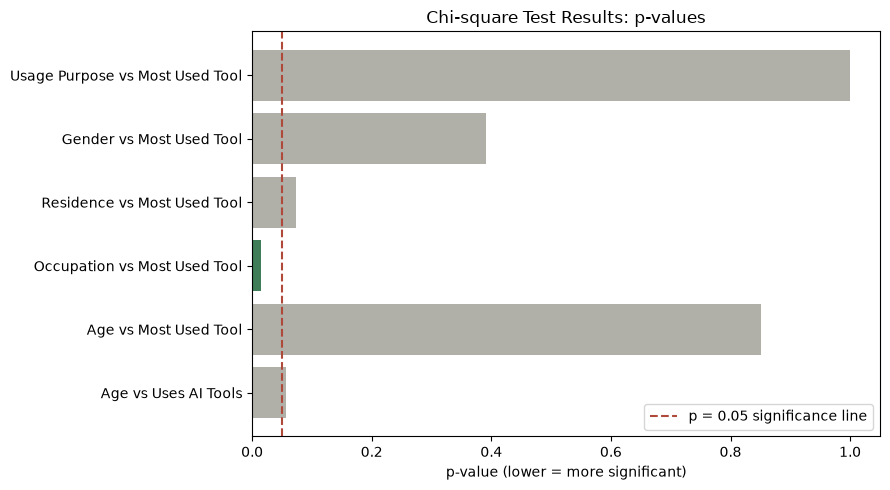

In [11]:
# Diagram: p-values at a glance, with the 0.05 significance line marked 
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#3F7D58' if sig else '#B0AFA8' for sig in summary['Significant (p<0.05)']]
labels = [t.replace('_', ' ') for t in summary['Test']]
ax.barh(labels, summary['p_value'], color=colors)
ax.axvline(0.05, color='#AF4A3B', linestyle='--', linewidth=1.5, label='p = 0.05 significance line')
ax.set_xlabel('p-value (lower = more significant)')
ax.set_title('Chi-square Test Results: p-values')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [12]:
#  Reading the result
# Occupation is the only variable with a confirmed statistical association to
# tool choice (p = 0.015). Age vs usage (p = 0.056) and Residence vs tool
# (p = 0.074) sit just above the significance line -- worth re-testing with a
# larger sample rather than dismissing. Occupation has 14 categories and
# several very small groups, so this result should be read as suggestive
# rather than definitive.
print("Significant tests:", summary['Significant (p<0.05)'].sum(), "of", len(summary))


Significant tests: 1 of 6
